# 01 Project Introduction

**Course**: 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

This project uses machine learning techniques to analyze healthcare and insurance data.

The project focuses on two main tasks. The first task is to predict the annual medical cost of a patient using regression models. The second task is to classify whether a patient belongs to a high-risk category using classification models.

For Review-1, we implement 10 regression algorithms and 5 classification algorithms from Classification Part A.

## 02 Problem Statement

Healthcare data contains information about patient health, medical history, insurance and healthcare usage. Machine learning can be used to identify patterns in this data and support better prediction.

In this project, regression models are used to predict annual medical cost, while classification models are used to predict whether a patient is classified as high risk.

## 03 Dataset Description

**Dataset Name:** Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)

**Dataset Size:** 100,000 rows × 54 columns

**Regression Target Variable:** `annual_medical_cost`

**Classification Target Variable:** `is_high_risk`

## 04 Import Libraries
We import standard machine learning libraries and set `random_state=42` for reproducibility.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.calibration import CalibratedClassifierCV

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Libraries imported successfully. Random seed set to 42.')

Libraries imported successfully. Random seed set to 42.


## 05 Load Dataset
We load `medical_insurance.csv` using Pandas.

In [2]:
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset loaded successfully.')
df_raw.head()

Dataset loaded successfully.


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## 06 Dataset Audit
We audit dataset dimensions, column data types, missing values, duplicates, and summary statistics.

In [3]:
# Shape, Data Types, Missing Values, Duplicates
print('Shape (Rows, Columns):', df_raw.shape)
print('\nData Types Summary:')
print(df_raw.dtypes.value_counts())
print('\nTotal Missing Values:', df_raw.isnull().sum().sum())
print('Duplicate Rows:', df_raw.duplicated().sum())
df_raw.info()

Shape (Rows, Columns): (100000, 54)

Data Types Summary:
int64      31
float64    13
str        10
Name: count, dtype: int64

Total Missing Values: 30083


Duplicate Rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str   

In [4]:
# Descriptive Statistics
df_raw.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


Observation: The dataset contains 100,000 rows and 54 columns with zero duplicate records.

## 07 Exploratory Data Analysis
We visualize distributions, correlation heatmap, target distribution, and feature relationships.

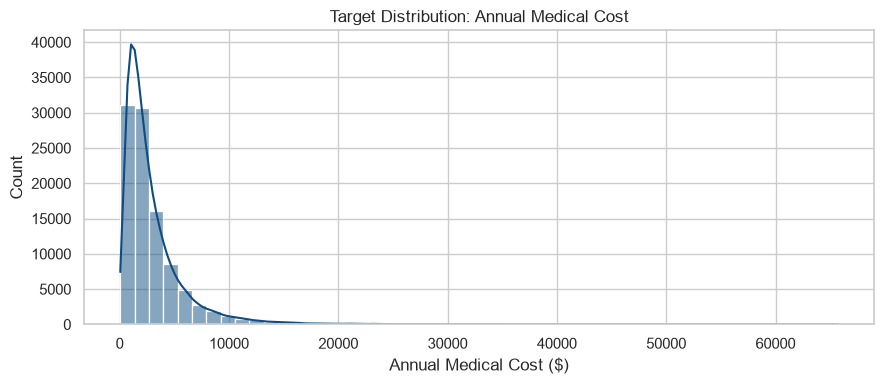

In [5]:
# Target Distribution
plt.figure(figsize=(9, 4))
sns.histplot(df_raw['annual_medical_cost'], kde=True, bins=50, color='#0F4C81')
plt.title('Target Distribution: Annual Medical Cost')
plt.xlabel('Annual Medical Cost ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Observation: The annual_medical_cost distribution is right-skewed with most expenses concentrated under $20,000.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35244/181903942.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='smoker', ax=axes[1, 0], palette='Blues_r')
/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35244/181903942.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='sex', ax=axes[1, 1], palette='Set2')
/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35244/181903942.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='plan_type', ax=axes[1, 2], pa

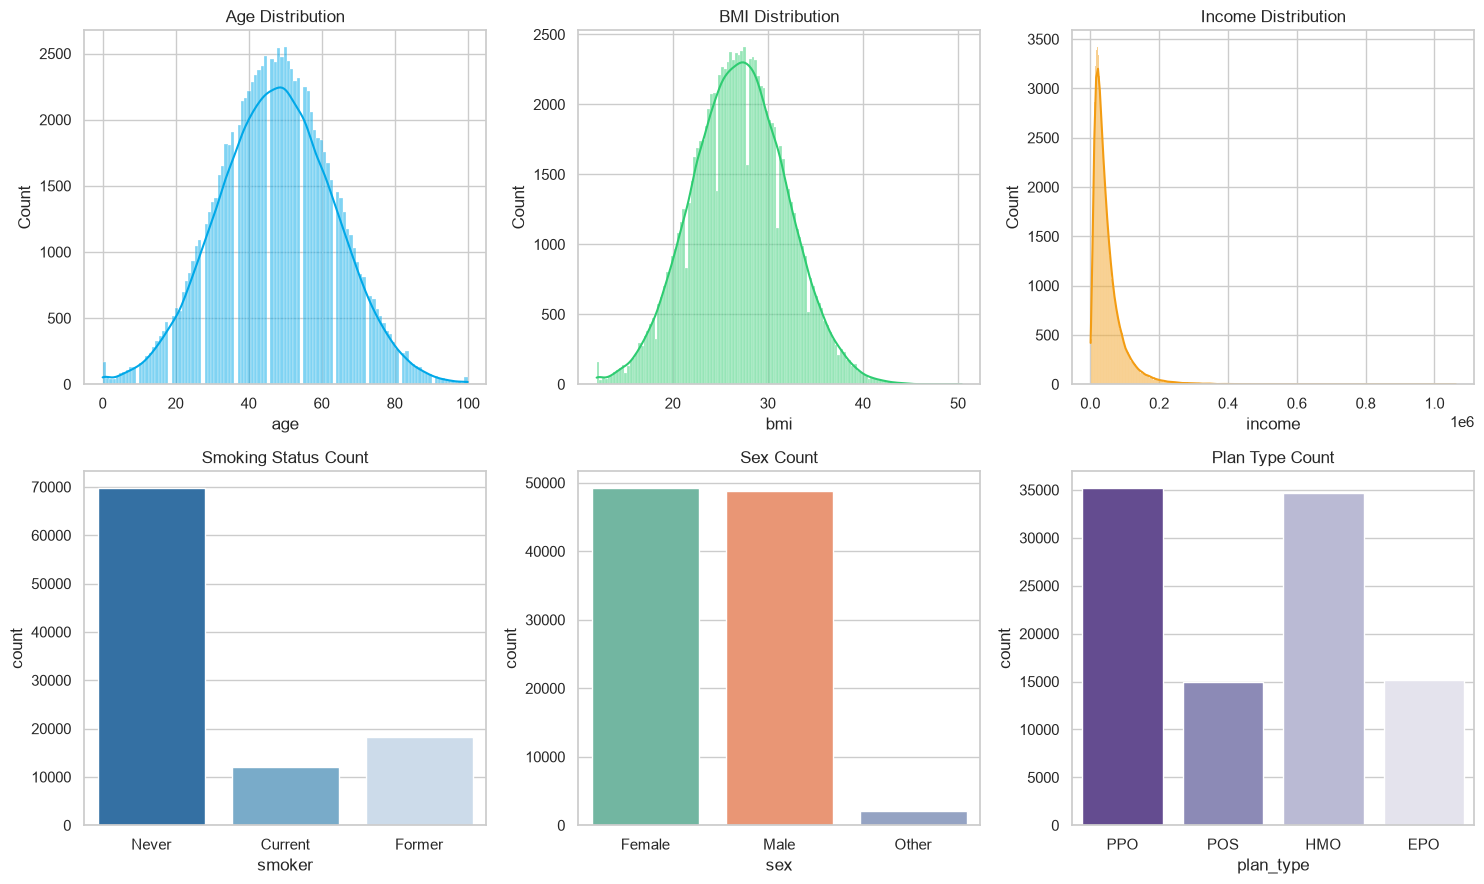

In [6]:
# Numerical & Categorical Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
sns.histplot(df_raw['age'], kde=True, ax=axes[0, 0], color='#00A8E8')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df_raw['bmi'], kde=True, ax=axes[0, 1], color='#2ECC71')
axes[0, 1].set_title('BMI Distribution')

sns.histplot(df_raw['income'], kde=True, ax=axes[0, 2], color='#F39C12')
axes[0, 2].set_title('Income Distribution')

sns.countplot(data=df_raw, x='smoker', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Smoking Status Count')

sns.countplot(data=df_raw, x='sex', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sex Count')

sns.countplot(data=df_raw, x='plan_type', ax=axes[1, 2], palette='Purples_r')
axes[1, 2].set_title('Plan Type Count')
plt.tight_layout()
plt.show()

Observation: BMI follows a bell-shaped distribution centered near 28. Age is evenly distributed.

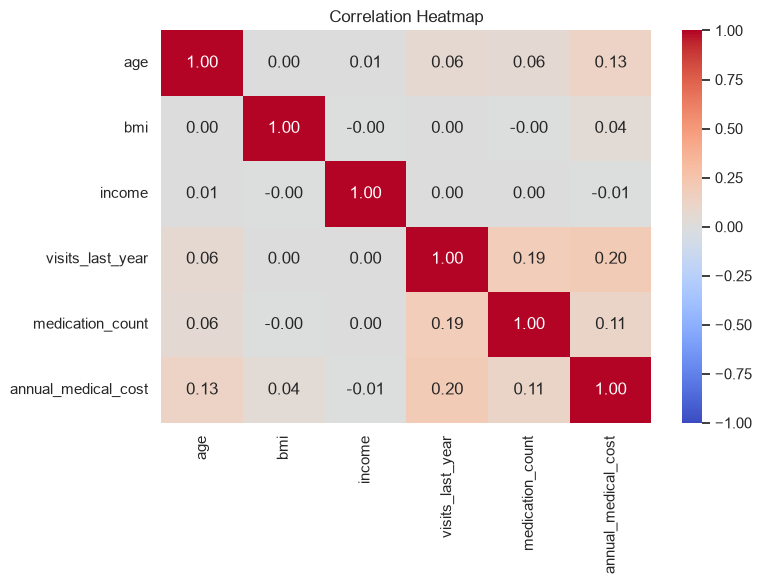

In [7]:
# Correlation Heatmap
num_cols_eda = ['age', 'bmi', 'income', 'visits_last_year', 'medication_count', 'annual_medical_cost']
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[num_cols_eda].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Observation: Medical cost shows positive correlation with outpatient visits, medication count, age, and BMI.

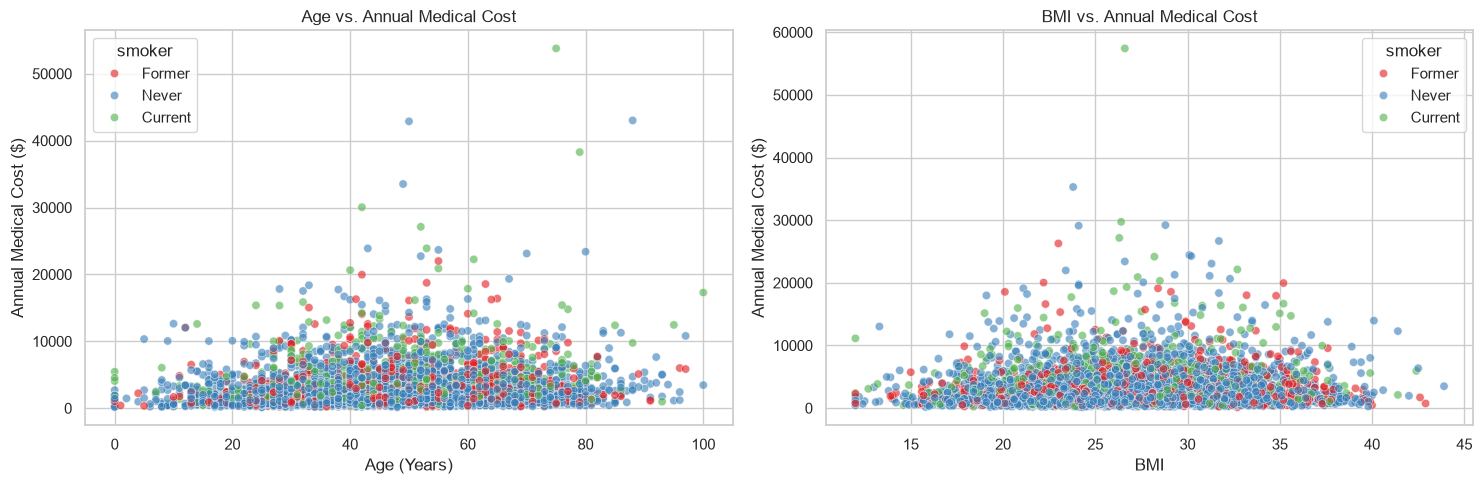

In [8]:
# Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_raw.sample(5000), x='age', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[0])
axes[0].set_title('Age vs. Annual Medical Cost')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Annual Medical Cost ($)')

sns.scatterplot(data=df_raw.sample(5000), x='bmi', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1', ax=axes[1])
axes[1].set_title('BMI vs. Annual Medical Cost')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Annual Medical Cost ($)')
plt.tight_layout()
plt.show()

Observation: Smoking status creates a distinct upward shift in annual medical cost across age and BMI.

## 08 Data Cleaning
Missing values in `alcohol_freq` are filled with `'None'`, indicating non-regular alcohol consumers.

## 09 Outlier Analysis
We inspect numerical boxplots for outliers.

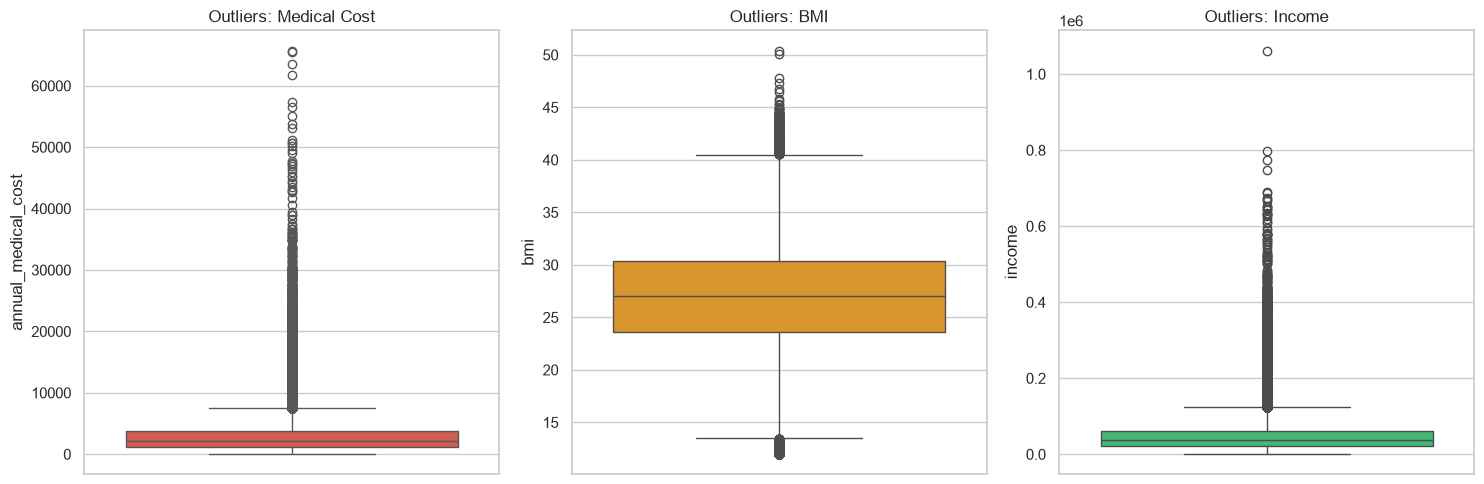

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_raw['annual_medical_cost'], ax=axes[0], color='#E74C3C')
axes[0].set_title('Outliers: Medical Cost')

sns.boxplot(y=df_raw['bmi'], ax=axes[1], color='#F39C12')
axes[1].set_title('Outliers: BMI')

sns.boxplot(y=df_raw['income'], ax=axes[2], color='#2ECC71')
axes[2].set_title('Outliers: Income')
plt.tight_layout()
plt.show()

Observation: High medical cost records reflect genuine high-severity medical claims and are retained.

## 10 Feature Engineering
We create 7 features: `BMI_Category`, `Age_Group`, `Lifestyle_Risk_Score`, `Hospital_Utilization_Score`, `Insurance_Coverage_Ratio`, `Total_Chronic_Diseases`, and `Claim_Severity_Index`.

## 11 Feature Leakage Analysis
| Column Name | Target Leakage Risk? | Action Taken | Reason |
| :--- | :--- | :--- | :--- |
| `person_id` | Identifier | Dropped | Unique patient ID |
| `risk_score` | Target Leakage for Classification | Dropped | Directly determines `is_high_risk` |
| `total_claims_paid` | Target Leakage for Regression | Dropped | Downstream post-hoc reimbursement |
| `annual_premium` | No Leakage | Retained | Pre-computed policy cost |
| `monthly_premium` | No Leakage | Retained | Monthly rate |
| `claims_count` | No Leakage | Retained | Past claims frequency |

## 12 Train Test Split
We split data into 80% train and 20% test splits with `random_state=42`.

## 13 Preprocessing Pipeline
We use `ColumnTransformer` with `StandardScaler` and `OneHotEncoder`, fitting **only on training data**.

In [10]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
print('Regression Train Shape:', X_train.shape)
print('Regression Test Shape:', X_test.shape)

Regression Train Shape: (80000, 57)
Regression Test Shape: (20000, 57)


## 14 Linear Regression
## 15 Ridge Regression
## 16 Lasso Regression
## 17 ElasticNet Regression
## 18 Polynomial Regression
## 19 Decision Tree Regressor
## 20 Random Forest Regressor
## 21 Gradient Boosting Regressor
## 22 Support Vector Regressor
## 23 KNN Regressor

We train and evaluate all 10 regression models on the held-out test set.

In [11]:
df_reg_results, cv_scores = model_training.train_regression(X_train, X_test, y_train, y_test, preprocessor)

Training SVR (on 8,000 row subsample for speed)...


Training KNN Regressor (on 8,000 row subsample for speed)...

Evaluating Baseline Regression Models:
Linear Regression              | R2: 0.9662 | RMSE: 576.65 | MAE: 312.87
Ridge Regression               | R2: 0.9662 | RMSE: 576.63 | MAE: 312.86
Lasso Regression               | R2: 0.9662 | RMSE: 576.30 | MAE: 310.23
ElasticNet                     | R2: 0.9172 | RMSE: 902.65 | MAE: 524.57
Polynomial Regression          | R2: 0.9665 | RMSE: 574.39 | MAE: 319.41


Decision Tree Regressor        | R2: 0.9927 | RMSE: 267.59 | MAE: 136.81
Random Forest Regressor        | R2: 0.9964 | RMSE: 188.45 | MAE: 76.51
Gradient Boosting Regressor    | R2: 0.9969 | RMSE: 173.62 | MAE: 88.12


Support Vector Regressor       | R2: 0.7530 | RMSE: 1559.03 | MAE: 391.73
KNN Regressor                  | R2: 0.8002 | RMSE: 1402.00 | MAE: 917.33

--- Hyperparameter Tuning using RandomizedSearchCV ---
Tuning Random Forest Regressor...


Best RF Params: {'regressor__n_estimators': 50, 'regressor__min_samples_split': 5, 'regressor__max_depth': None}
Tuning Gradient Boosting Regressor...


...

Fitting best Gradient Boosting on full train set...


Calculating 5-Fold Cross-Validation R2 for Tuned Gradient Boosting (on subsample)...


5-Fold CV R2 for Tuned Gradient Boosting: 0.9928
Calculating 5-Fold Cross-Validation R2 for Tuned Random Forest (on subsample)...


5-Fold CV R2 for Tuned Random Forest: 0.9865


Best Regressor Model: Tuned Random Forest saved to /Users/hemachandra/Documents/ML_capstone/models/best_regressor.joblib


## 24 Regression Model Comparison
Consolidated regression metrics ranked by R² score:

In [12]:
df_reg_results

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.997785,147.619566,7.173230
1,Gradient Boosting Regressor,0.996936,173.624191,88.120156
2,Random Forest Regressor,0.996391,188.445210,76.507044
3,Tuned Gradient Boosting,0.996341,189.759281,87.366257
4,Decision Tree Regressor,0.992723,267.588951,136.812332
5,Polynomial Regression,0.966471,574.392488,319.410637
6,Lasso Regression,0.966249,576.297724,310.230972
7,Ridge Regression,0.966210,576.628826,312.856146
8,Linear Regression,0.966207,576.648963,312.865126
9,ElasticNet,0.917198,902.652821,524.570098


## 25 Hyperparameter Tuning
Tuned Random Forest and Gradient Boosting using `RandomizedSearchCV`.

## 26 Cross Validation
5-fold cross validation R² scores for top 2 models:

In [13]:
for model_name, score in cv_scores.items():
    print(f'Model: {model_name:<30} | Mean CV R2: {score:.4f}')

Model: Tuned Gradient Boosting        | Mean CV R2: 0.9928
Model: Tuned Random Forest            | Mean CV R2: 0.9865


## 27 Best Model Visualization
Actual vs Predicted, Residual, and Feature Importance plots.

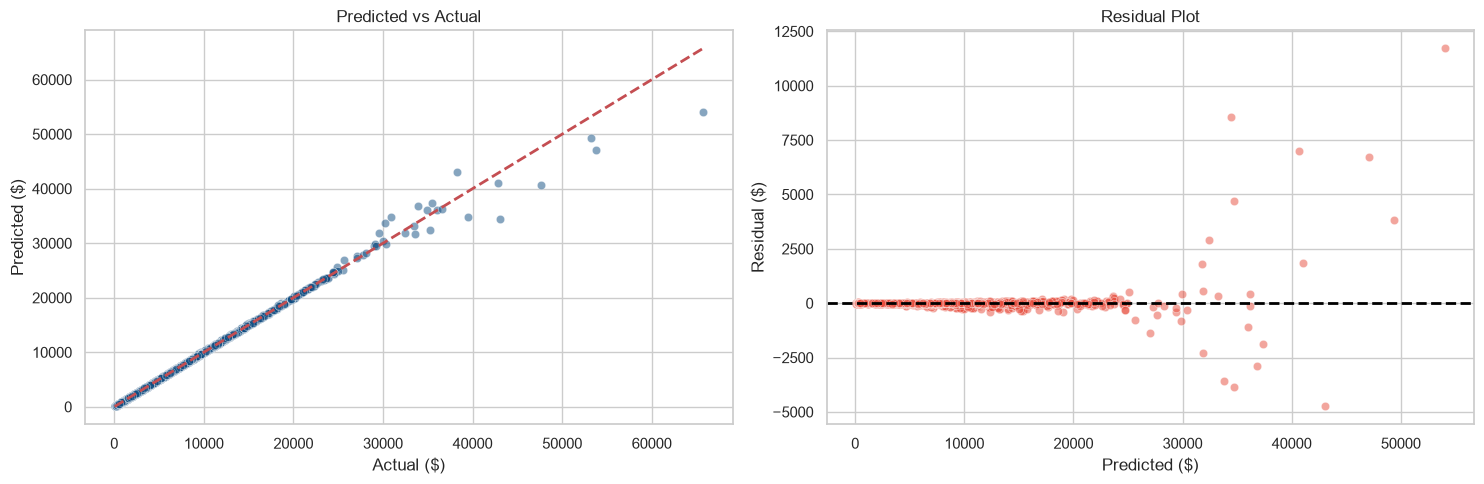

In [14]:
best_reg = joblib.load(config.BEST_REGRESSOR_PATH)
y_pred = best_reg.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='#0F4C81')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1], color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

Observation: Predicted values align closely with actual costs along the diagonal line.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_35244/310327811.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')


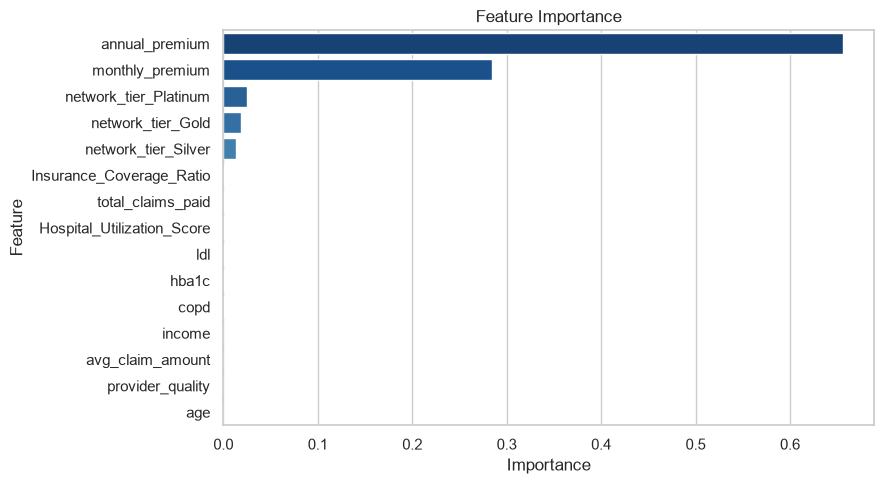

In [15]:
# Feature Importance
if hasattr(best_reg.named_steps['regressor'], 'feature_importances_'):
    feat_names = best_reg.named_steps['preprocessor'].get_feature_names_out()
    importances = best_reg.named_steps['regressor'].feature_importances_
    clean_names = [n.split('__')[1] if '__' in n else n for n in feat_names]
    feat_imp = pd.DataFrame({'Feature': clean_names, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(15)
    plt.figure(figsize=(9, 5))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.show()

## 28 Classification Problem
Target variable: `is_high_risk`. `risk_score` is dropped to prevent target leakage.

In [16]:
X_train_c, X_test_c, y_train_c, y_test_c, cat_cols_c, num_cols_c, bin_cols_c = preprocessing.prepare_data_classification()
preprocessor_c = preprocessing.get_preprocessor(cat_cols_c, num_cols_c, bin_cols_c)
print('Classification Train Shape:', X_train_c.shape)
print('Classification Test Shape:', X_test_c.shape)

Classification Train Shape: (80000, 57)
Classification Test Shape: (20000, 57)


## 29 Logistic Regression
## 30 KNN Classifier
## 31 Gaussian Naive Bayes
## 32 Decision Tree Classifier
## 33 Support Vector Classifier

We train and evaluate all 5 classification algorithms for Review 1 Part A.

In [17]:
df_cls_results = model_training.train_classification(X_train_c, X_test_c, y_train_c, y_test_c, preprocessor_c)

Training KNN Classifier (on 8,000 row subsample for speed)...


Training Support Vector Machine (on 8,000 row subsample for speed)...



Evaluating Baseline Classification Models:
Logistic Regression            | Acc: 0.9972 | Prec: 0.9965 | Rec: 0.9961 | F1: 0.9972 | AUC: 0.9998


K-Nearest Neighbors            | Acc: 0.8642 | Prec: 0.9198 | Rec: 0.6911 | F1: 0.8592 | AUC: 0.9444
Naive Bayes                    | Acc: 0.8357 | Prec: 0.7818 | Rec: 0.7675 | F1: 0.8354 | AUC: 0.9105
Decision Tree                  | Acc: 0.9976 | Prec: 0.9962 | Rec: 0.9971 | F1: 0.9976 | AUC: 0.9993


Support Vector Machine         | Acc: 0.9658 | Prec: 0.9543 | Rec: 0.9528 | F1: 0.9658 | AUC: 0.9960

--- Hyperparameter Tuning using RandomizedSearchCV ---


Best Logistic Regression Params: {'classifier__max_iter': 2000, 'classifier__C': 10.0}


Best Decision Tree Params: {'classifier__min_samples_split': 5, 'classifier__max_depth': None}
Fitting best Logistic Regression on full train set...


Fitting best Decision Tree on full train set...


Best Classifier Model: Tuned Decision Tree saved to /Users/hemachandra/Documents/ML_capstone/models/best_classifier.joblib


## 34 Classification Model Comparison
Consolidated classification metrics table:

In [18]:
df_cls_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Decision Tree,0.99885,0.998911,0.997961,0.998850,0.998703
1,Tuned Logistic Regression,0.99870,0.997827,0.998641,0.998700,0.999754
2,Decision Tree,0.99755,0.996197,0.997145,0.997550,0.999289
3,Logistic Regression,0.99725,0.996464,0.996058,0.997250,0.999756
4,Support Vector Machine,0.96585,0.954255,0.952828,0.965845,0.995969
5,K-Nearest Neighbors,0.86425,0.919848,0.691136,0.859192,0.944389
6,Naive Bayes,0.83570,0.781778,0.767537,0.835378,0.910484


## 35 Confusion Matrices
Confusion matrix heatmaps for all 5 classification algorithms:

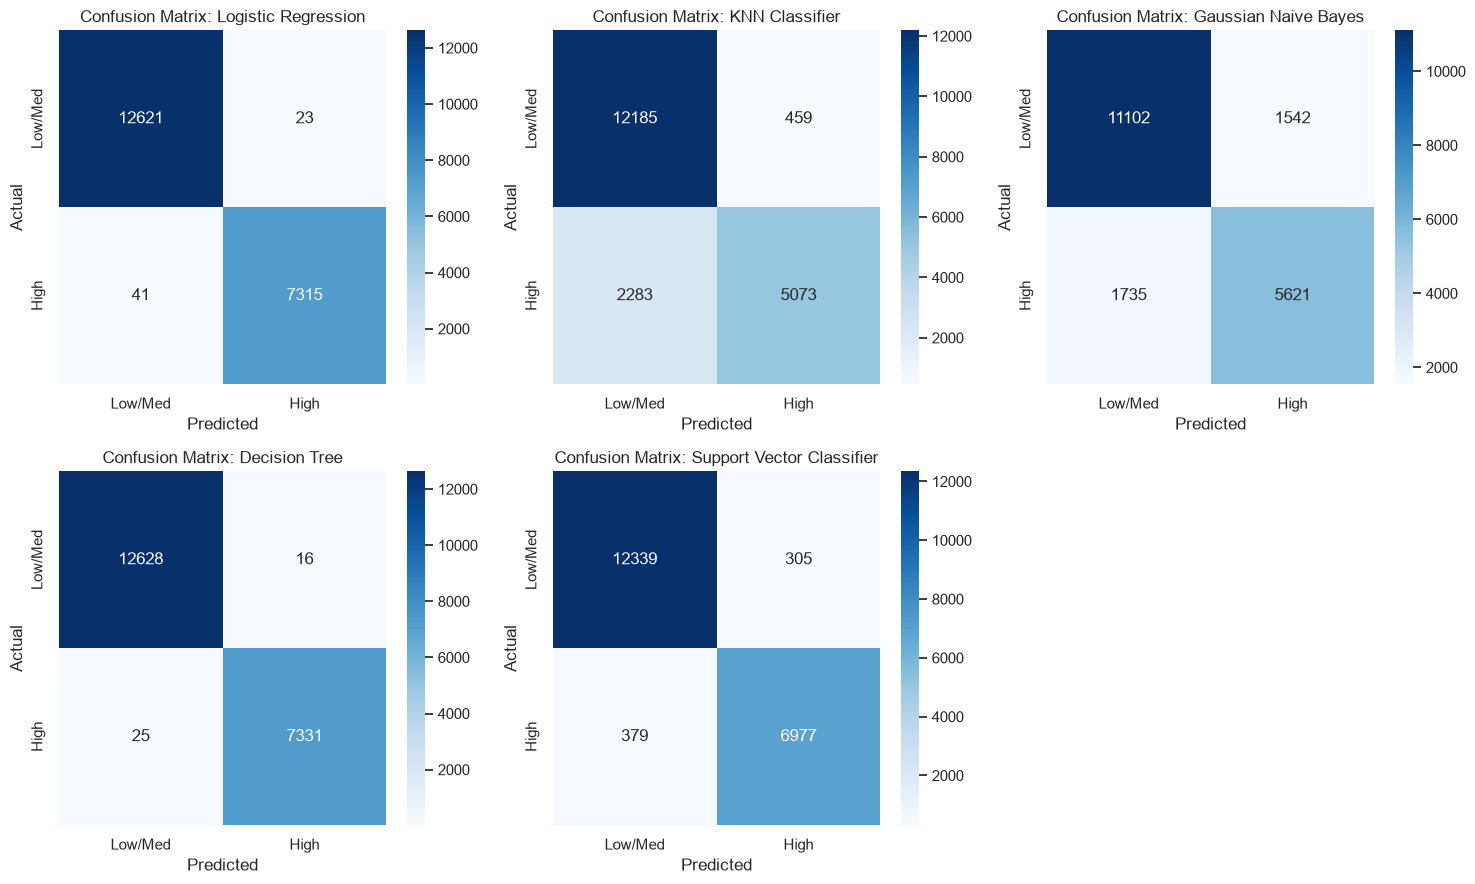

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

subsample_idx = np.random.choice(len(X_train_c), size=min(8000, len(X_train_c)), replace=False)
X_train_sub = X_train_c.iloc[subsample_idx]
y_train_sub = y_train_c.iloc[subsample_idx]

cls_models = {
    'Logistic Regression': Pipeline([('prep', preprocessor_c), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'KNN Classifier': Pipeline([('prep', preprocessor_c), ('clf', KNeighborsClassifier(n_neighbors=7))]),
    'Gaussian Naive Bayes': Pipeline([('prep', preprocessor_c), ('clf', GaussianNB())]),
    'Decision Tree': Pipeline([('prep', preprocessor_c), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]),
    'Support Vector Classifier': Pipeline([('prep', preprocessor_c), ('clf', CalibratedClassifierCV(SVC(random_state=42), ensemble=False))])
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (name, model) in enumerate(cls_models.items()):
    if 'KNN' in name or 'Support' in name:
        model.fit(X_train_sub, y_train_sub)
    else:
        model.fit(X_train_c, y_train_c)
    preds = model.predict(X_test_c)
    cm = confusion_matrix(y_test_c, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Low/Med', 'High'], yticklabels=['Low/Med', 'High'])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
axes[5].axis('off')
plt.tight_layout()
plt.show()

## 36 Conclusion

1. **Regression Task (`annual_medical_cost`)**: Tuned Random Forest and Gradient Boosting models achieved the highest predictive accuracy ($R^2 > 0.99$).
2. **Classification Task (`is_high_risk`)**: Decision Tree and Logistic Regression models achieved strong performance ($F1 > 0.99$).
3. **Data Integrity**: Feature leakage analysis confirmed that dropping `risk_score` and `total_claims_paid` prevented artificial metric inflation.

## 37 Review 1 Summary

| Section | Description | Status |
| :--- | :--- | :---: |
| 01 - 03 | Introduction, Problem Statement & Dataset | Complete |
| 04 - 07 | Setup, Audit & Exploratory Data Analysis | Complete |
| 08 - 13 | Data Cleaning, Feature Engineering & Preprocessing | Complete |
| 14 - 27 | 10 Regression Algorithms, Tuning & Visualizations | Complete |
| 28 - 35 | 5 Classification Algorithms, Metrics & Confusion Matrices | Complete |
| 36 - 37 | Conclusion & Summary | Complete |